# Simulação de Epidemias  

Disciplina: Ciência de Redes

**Integrantes:**
- Anderson Falcão
- Leonardo Alexandre  
- Ramyro Corrêa


#### 0. Objetivo do Notebook

Este notebook contém a implementaçãoo das simulações do modelo **SIS (Suscetível-Infectado-Suscetível)** aplicado em dois tipos de redes:

- Rede aleatória
- Redes livre de escala

Ao longo do notebook, serão realizadas:

1. **Geração das redes** com 10.000 vértices e grau médio ≥ 20.  
2. **Simulações do processo epidêmico** para diferentes valores de β e μ.  
3. **Comparações entre simulações e resultados esperados pela teoria de campo médio.**  
4. **Estudo do limiar epidêmico: $ R_0 = \frac{\beta \langle k \rangle}{\mu} $.**  
5. **Experimentos de imunização** (aleatória, hubs e vizinhos) e análise da robustez da rede.

In [ ]:
# Dependências
import networkx as nx
import numpy as np
import random
import matplotlib.pyplot as plt
from tqdm import tqdm

#### 1. Simulação do Modelo SIS em Rede Aleatória (ER)

Gere uma rede aleatória (ER) com $10000$ vértices e grau médio $\langle k \rangle = 20$. Comece
com $5$ vértices infectados escolhidos aleatoriamente. Execute múltiplas simulações da
propagação da infecção pelo modelo SIS com os parâmetros abaixo e compare com os
resultados esperados. (sugestão: faça em torno de 100 simulações e descreva o
comportamento da epidemia “na média”)

**a.** $\beta = 0.02$ e $\mu = 0.1\\$ 
**b.** $\beta = 0.02$ e $\mu = 0.4$  
**c.** $\beta = 0.02$ e $\mu = 0.5$  

Mostre que $R_0 = \frac{\beta \langle k \rangle}{\mu} > 1$,  então a doença se fixa na rede no modelo SIS de campo médio.

In [2]:
def simulate_sis(G, beta, mu, initial_infected=5, steps=200):
    nodes = list(G.nodes())
    
    # Estado inicial
    infected = set(random.sample(nodes, initial_infected))
    infected_history = []

    for t in range(steps):
        new_infected = set(infected)

        # infecta
        for node in infected:
            for neighbor in G.neighbors(node):
                if neighbor not in infected and random.random() < beta:
                    new_infected.add(neighbor)

        # recupera
        for node in list(new_infected):
            if random.random() < mu:
                new_infected.remove(node)

        infected = new_infected
        infected_history.append(len(infected) / len(nodes))

    return infected_history

In [3]:
def run_experiments(G, beta, mu, runs=100, steps=200):
    all_runs = []

    for _ in tqdm(range(runs), desc=f"β={beta}, μ={mu}"):
        hist = simulate_sis(G, beta, mu, steps=steps)
        all_runs.append(hist)

    mean_curve = np.mean(all_runs, axis=0)
    return mean_curve

In [4]:
N = 10000
k = 20
p = k / (N - 1)

G = nx.erdos_renyi_graph(N, p)
print("Rede ER gerada.")

Rede ER gerada.


In [5]:
params = [
    (0.02, 0.1),
    (0.02, 0.4),
    (0.02, 0.5)
]

results = {}

for beta, mu in params:
    mean_curve = run_experiments(G, beta, mu, runs=100, steps=200)
    results[(beta, mu)] = mean_curve

β=0.02, μ=0.5: 100%|██████████| 100/100 [00:00<00:00, 3540.39it/s]


Convergiu para: 0.674
Convergiu para: 0.0
Convergiu para: 0.0


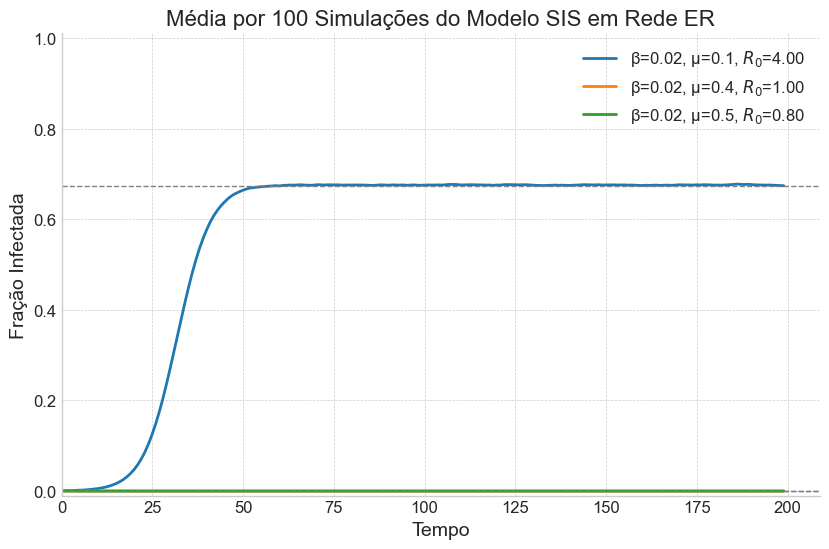

In [29]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12*0.7, 8*0.7))

custom_styles = [
    {"color": "C0", "linestyle": "-"},
    {"color": "C1", "linestyle": "-"},
    {"color": "C2", "linestyle": "-"}
]

for i, ((beta, mu), curve) in enumerate(results.items()):
    style = custom_styles[i % len(custom_styles)]
    
    R0 = beta * k / mu
    
    ax.plot(curve, 
            label=f"β={beta}, μ={mu}, $R_0$={R0:.2f}",
            color=style["color"],
            linestyle=style["linestyle"],
            linewidth=2)
    
    print("Convergiu para:", round(curve[-1],3))
    ax.axhline(y=curve[-1], color='gray', linestyle='--', linewidth=1.0)

# Configurações dos eixos e títulos
ax.set_xlabel("Tempo", fontsize=14)
ax.set_ylabel("Fração Infectada", fontsize=14)
ax.set_title("Média por 100 Simulações do Modelo SIS em Rede ER", fontsize=16)

# Configurações de grade e legenda
ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Tamanho da fonte dos ticks
ax.tick_params(axis='both', labelsize=12)

# Limites dos eixos
ax.set_ylim(bottom=-0.01, top=1.01)
ax.set_xlim(left=-0.01)

# Remoção das bordas superior e direita (Spines)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#### 2. Simulação do Modelo SIS em Rede Livre de Escala

Gere uma rede “livre de escala” com 10000 vértices, grau médio $\langle k \rangle = 20$ e
expoente $\gamma = 2.5$. Comece com $5$ vértices infectados escolhidos aleatoriamente. Execute
múltiplas simulações da propagação da infecção pelo modelo SIS com os parâmetros abaixo e
compare com os resultados esperados. (sugestão: faça em torno de $100$ simulações e descreva
o comportamento da epidemia “na média”)

**a.** $\beta = 0.01$ e $\mu = 0.1 \\$
**b.** $\beta = 0.01$ e $\mu = 0.2 \\$
**c.** $\beta = 0.01$ e $\mu = 0.3$

Descreva o comportamento da epidemia e compare com o item (1).

In [7]:
N = 10000
k_target = 20
gamma = 2.5
 
deg_seq_float = nx.utils.powerlaw_sequence(N, exponent=gamma) # graus com distribuição power-law
mean_deg = sum(deg_seq_float) / N

In [8]:
# reescala para ter grau médio ~ k_target
scale = k_target / mean_deg
deg_seq = [max(1, int(round(d * scale))) for d in deg_seq_float]

# garante que a soma dos graus seja par
if sum(deg_seq) % 2 == 1:
    deg_seq[0] += 1

G_sf_multi = nx.configuration_model(deg_seq) # gera a rede livre de escala (multigrafo)
G_sf = nx.Graph(G_sf_multi)                     
G_sf.remove_edges_from(nx.selfloop_edges(G_sf)) 

# grau médio real da rede
avg_deg_sf = sum(dict(G_sf.degree()).values()) / G_sf.number_of_nodes()
print("Rede livre de escala gerada.")
print("N =", G_sf.number_of_nodes(), " | grau médio ≈", avg_deg_sf)


Rede livre de escala gerada.
N = 10000  | grau médio ≈ 19.12


In [9]:
params_sf = [(0.01, 0.1), (0.01, 0.2), (0.01, 0.3)]
results_sf = {}

for beta, mu in params_sf:
    mean_curve = run_experiments(G_sf, beta, mu, runs=100, steps=200)
    results_sf[(beta, mu)] = mean_curve

β=0.01, μ=0.3: 100%|██████████| 100/100 [00:42<00:00,  2.33it/s]


Convergiu para: 0.366
Convergiu para: 0.111
Convergiu para: 0.024


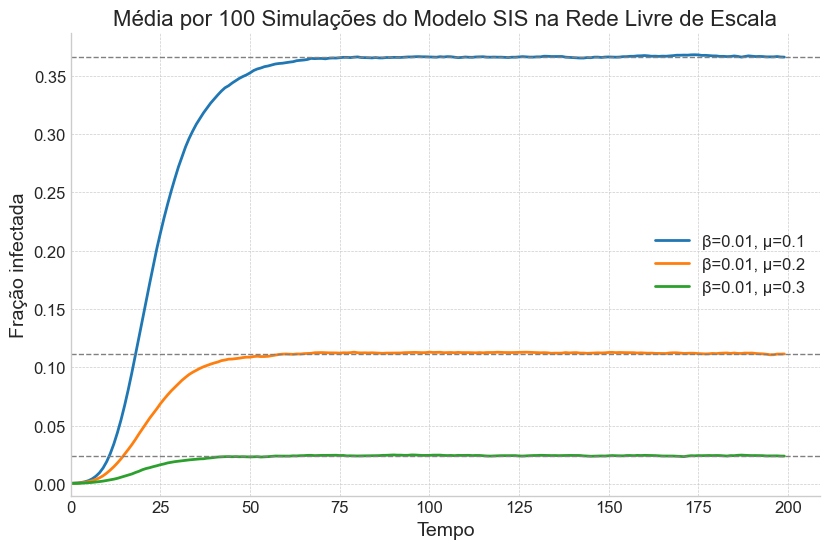

In [28]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12*0.7, 8*0.7))

custom_styles = [
    {"color": "C0", "linestyle": "-"},
    {"color": "C1", "linestyle": "-"},
    {"color": "C2", "linestyle": "-"}
]

for i, ((beta, mu), curve) in enumerate(results_sf.items()):
    style = custom_styles[i % len(custom_styles)]
    
    ax.plot(curve, 
            label=f"β={beta}, μ={mu}",
            color=style["color"],
            linestyle=style["linestyle"],
            linewidth=2,
            markevery=20)

    print("Convergiu para:", round(curve[-1],3))
    ax.axhline(y=curve[-1], color='gray', linestyle='--', linewidth=1.0)


### Configurações
ax.set_xlabel("Tempo", fontsize=14)
ax.set_ylabel("Fração infectada", fontsize=14)
ax.set_title("Média por 100 Simulações do Modelo SIS na Rede Livre de Escala", fontsize=16)

ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

ax.tick_params(axis='both', labelsize=12)

ax.set_ylim(bottom=-0.01)
ax.set_xlim(left=-0.01)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#### 3. Simulação do Modelo SIS em Rede Livre de Escala com Imunização
Considere o exercício anterior, letra a. Descubra o número de vértices imunizados 
previamente que são necessários para impedir a fixação do estado endêmico nos seguintes 
cenários: 

$a.$ Os vértices imunizados são escolhidos aleatoriamente.  
$b.$ Os vértices imunizados são os de maior grau (hubs).  
$c.$ Os vértices imunizados são os vizinhos de vértices escolhidos aleatoriamente. 

Descreva (brevemente, com um ou dois parágrafos) como a fração de vacinados em cada caso 
se relaciona com o tema de robustez da rede visto em sala de aula.

In [11]:
def apply_immunization(G, strategy, fraction):
    """
    Retorna uma cópia do grafo com 'fraction' dos vértices removidos (imunizados)
    de acordo com a estratégia.
    """
    G_imm = G.copy()
    N = G.number_of_nodes()
    num_to_remove = int(N * fraction)
    
    if num_to_remove == 0:
        return G_imm

    nodes_to_remove = []

    if strategy == "random": # a. Escolha aleatória
        nodes_to_remove = random.sample(list(G.nodes()), num_to_remove)

    elif strategy == "hubs": # b. Escolha dos maiores graus (Hubs)
        # Ordena nós pelo grau (decrescente) e pega os top 'num_to_remove'
        sorted_nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)
        nodes_to_remove = [n for n, d in sorted_nodes[:num_to_remove]]

    elif strategy == "neighbors": # c. Vizinhos de aleatórios (Acquaintance Immunization)
        nodes_list = list(G.nodes())
        target_set = set()
        
        while len(target_set) < num_to_remove:
            # Escolhe um nó aleatório
            u = random.choice(nodes_list)
            neighbors = list(G.neighbors(u))
            if neighbors:
                # Imuniza um vizinho aleatório dele
                v = random.choice(neighbors)
                target_set.add(v)
            else:
                # Se for isolado, imuniza ele mesmo (para evitar loop infinito)
                target_set.add(u)
                
        nodes_to_remove = list(target_set)

    # Remove os nós (simulando imunização perfeita)
    G_imm.remove_nodes_from(nodes_to_remove)
    return G_imm

def find_critical_fraction(G_original, beta, mu, strategy, fractions):
    """
    Testa várias frações de imunização e retorna a prevalência final média para cada uma.
    """
    final_prevalence = []
    
    print(f"Testando estratégia: {strategy}...")
    
    for f in fractions:
        # Aplica imunização
        G_imm = apply_immunization(G_original, strategy, f)
        
        # Se a rede ficou vazia ou muito desconexa, prevalência é 0
        if G_imm.number_of_nodes() == 0:
            final_prevalence.append(0)
            continue
            
        try:
            curve = run_experiments(G_imm, beta, mu, runs=20, steps=200)
            final_val = curve[-1] # Pega o valor final de equilíbrio
            final_prevalence.append(final_val)
        except:
            print("Entrou no except (nao deveria acontecer)")
            final_prevalence.append(0)

    return final_prevalence

In [12]:
# Parâmetros do exercício 2 letra a
beta_target = 0.01
mu_target = 0.1

# Lista de frações de vacinação a testar (0% a 95%, passos de 5%)
fractions = np.arange(0.0, 1.0, 0.05)

strategies = ["random", "hubs", "neighbors"]
results_imm = {}

# utilizando G_sf da questão 2)
for strat in strategies:
    prevalences = find_critical_fraction(G_sf, beta_target, mu_target, strat, fractions)
    results_imm[strat] = prevalences

Testando estratégia: random...


β=0.01, μ=0.1: 100%|██████████| 20/20 [00:00<00:00, 2411.07it/s]


Testando estratégia: hubs...


β=0.01, μ=0.1: 100%|██████████| 20/20 [00:00<00:00, 3065.90it/s]


Testando estratégia: neighbors...


β=0.01, μ=0.1: 100%|██████████| 20/20 [00:00<00:00, 2597.25it/s]


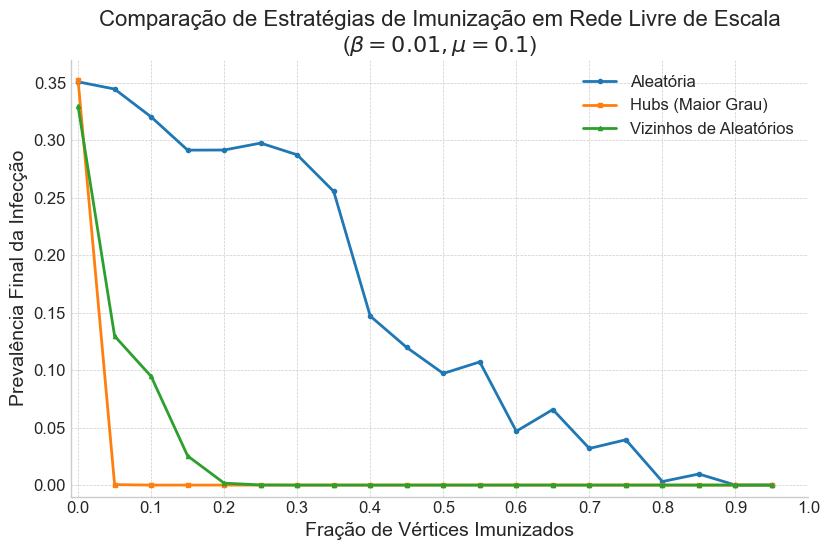

In [30]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12*0.7, 8*0.7))

plot_styles = {
    "random": {"color": "C0", "marker": "o", "linestyle": "-", "label": "Aleatória"},
    "hubs": {"color": "C1", "marker": "s", "linestyle": "-", "label": "Hubs (Maior Grau)"},
    "neighbors": {"color": "C2", "marker": "^", "linestyle": "-", "label": "Vizinhos de Aleatórios"}
}

for strat in strategies:
    style = plot_styles[strat]
    ax.plot(fractions, results_imm[strat], 
             marker=style["marker"], 
             linestyle=style["linestyle"],
             color=style["color"],
             label=style["label"],
             markersize=3, 
             linewidth=2)

ax.set_xlabel("Fração de Vértices Imunizados", fontsize=14)
ax.set_ylabel("Prevalência Final da Infecção", fontsize=14)
ax.set_title(f"Comparação de Estratégias de Imunização em Rede Livre de Escala\n($\\beta={beta_target}, \\mu={mu_target}$)", fontsize=16)
ax.legend(fontsize=12)

ax.grid(True, which='both', linestyle='--', linewidth=0.5)

ax.set_xticks(np.arange(0, 1.05, 0.1))
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.set_ylim(bottom=-0.01)
ax.set_xlim(left=-0.01)

# Remove a linha superior e a direita da caixa do gráfico
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()